# Looking into Functional Data

## What is Functional Data?

In functional data analysis (FDA) each data point is a function $f: [a,b] \rightarrow \mathbb{R}$. I.e. each observation is some sort of curve. Instead of $x_i \in mathbb{R}^d$ we have $f_i(t)$ with our dataset being $\{f_1,f_2,\dots,f_n\}$. So each point lives in an infinite-dimensional function space, like $L^2[a,b]$. This means all square-integrable functions on $[a,b]$. This space contains addition, scalar multiplication, and an inner product $\langle f,g\rangle = \int_a^b f(t)g(t)\,dt$. Thus, this is a Hilbert space with each curve being a point in an infinite-dimensional space. 

## What is the distance between two functions then?

Most commonly, the distance between two functions would be 

$$\|f-g\|_{L^2} = \sqrt{\int_a^b (f(t)-g(t))^2 dt}$$ 
(l2_weighted)

which measures the "total energy" difference between the two curves with large differences over large intervals increasing the distance.

Another option is the Sup norm:

$$\|f-g\|_\infty = \max_{t \in [a,b]} |f(t)-g(t)|$$ 
(linf)

which is the maximum vertical deviation.

Finally, we also have the Sobolev $(H^1)$ norm:

$$\|f-g\|_{H^1}^2 = \int (f-g)^2 + \lambda \int (f'-g')^2$$ 
(h1)

which captures shape similarity.

## How can we turn infinite-dimensional data into finite data?

We must discretize the interval and choose a grid i.e. $t_1 < t_2 < \dots < t_m$. So each curve now becomes $x_i = \big(f_i(t_1),\dots,f_i(t_m)\big)\in \mathbb{R}^m$. Thus, we embed $L^2[a,b] \approx \mathbb{R}^m$. 

However, if we use our Euclidean distance in $\mathbb{R}^m$ we are computing:
$$\sqrt{\sum (f_i(t_k)-f_j(t_k))^2}$$
which ignores grid spacing. To counter this we weight by $\sqrt{\Delta t} $ such that:

$$\sum (f_i-f_j)^2 \Delta t$$ 

approximates the true integral. I.e. the discrete metric converges to the real functional norm as $m \rightarrow \infty$

## How to implement in VR Construction

Given $\varepsilon$ we connect curves $f_i$ and $f_j$ if $d(f_i,f_j) \leq \varepsilon$. So, if three curves are pairwise within $\varepsilon$, we add a 2-simplex and so on for any other number of curves being pairwise within each other. 


## What does the EC mean here?

Here we could roughly say $\chi = $ number of clusters of similar curves - cyclic interconnection structure ...

The ECC tells you how many distinct curve types exist and how separated they are. 

# Notes

Here we are sampling functions in three families with domain $t \in [0,1]$:

1. Sines

$$f_i(t) = A_{i}\text{sin}(w_{i}t + \phi_i)$$

with 
$A_i \sim \text{Uniform}(0.7,1.3)$
$w_i \sim \text{Uniform}(1,4)$
$\phi_i \sim \text{Uniform}(0,2\pi)$

This is a 3-parameter nonlinear manifold inside function space. So the data is random samples from a smooth 3D manifold embedded in $L^2$.

2. Bumps

For each curve choose $k \in \{1,2,3\}$ and add $k$ bumps with each bump being:
$$amp \cdot \exp\left(-\frac12 \left(\frac{t-\mu}{\sigma}\right)^2\right)$$
with 
$\mu \sim \text{Uniform}(0,1)$
$\sigma \sim \text{Uniform}(0.05,0.2)$
$amp \sim \text{Uniform}(0.6,1.4)$

So a full curve is:

$$f_i(t) = \sum_{j=1}^{k_i} a_{ij} \exp\left( -\frac12 \left(\frac{t-\mu_{ij}}{\sigma_{ij}}\right)^2 \right)$$

which is a finite mixture of normal curves. This does not form a fixed-dimension manifold.

3. Polynomials

$$f_i(t) = c_{i0} + c_{i1}t + c_{i2}t^2 + c_{i3}t^3 + c_{i4}t^4$$

with $c_{ij} \sim N(0, 0.5^2)$.

Thus, this is $\text{span}\{1,t,t^2,t^3,t^4\}$ which is a 5-dimensional linear subspace of $L^2$

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Literal

Metric = Literal["euclidean", "l2_weighted", "linf", "h1"]

# Curves / functional data utils
def make_grid(a: float, b: float, m: int) -> np.ndarray:
    if m < 2:
        raise ValueError("m must be >= 2")
    if not (b > a):
        raise ValueError("require b > a")
    return np.linspace(a, b, m)


def sample_curves(
    family: str,
    n: int,
    t: np.ndarray,
    seed: int = 0,
    noise: float = 0.0,
) -> np.ndarray:
    """
    Returns X with shape (n, m) where each row is a curve sampled on grid t.
    Families: 'sines', 'bumps', 'polynomials'
    """
    rng = np.random.default_rng(seed)
    t = np.asarray(t, dtype=float)
    m = t.size

    fam = (family or "sines").lower().strip()
    X = np.empty((n, m), dtype=float)

    if fam in {"sines", "sine"}:
        A = rng.uniform(0.7, 1.3, size=n)
        w = rng.uniform(1.0, 4.0, size=n)
        ph = rng.uniform(0.0, 2*np.pi, size=n)
        for i in range(n):
            X[i] = A[i] * np.sin(w[i] * t + ph[i])

    elif fam in {"bumps"}:
        for i in range(n):
            k = rng.integers(1, 4)  # 1..3 bumps
            y = np.zeros_like(t)
            for _ in range(k):
                mu = rng.uniform(t.min(), t.max())
                sig = rng.uniform(0.05*(t.max()-t.min()), 0.2*(t.max()-t.min()))
                amp = rng.uniform(0.6, 1.4)
                y = y + amp * np.exp(-0.5 * ((t - mu) / sig) ** 2)
            X[i] = y

    elif fam in {"polynomials", "poly"}:
        deg = 4
        for i in range(n):
            coef = rng.normal(scale=0.5, size=deg+1)
            y = np.zeros_like(t)
            for c in coef[::-1]:
                y = y * t + c
            X[i] = y

    else:
        raise ValueError("Unknown family. Use: sines, bumps, polynomials.")

    if noise > 0:
        X = X + rng.normal(0.0, noise, size=X.shape)

    return X



# Distances for functional curves
def pairwise_dist(
    X: np.ndarray,
    *,
    metric: Metric = "l2_weighted",
    t: np.ndarray | None = None,
    h1_lambda: float = 1.0,
) -> np.ndarray:
    """
    Pairwise distances between rows of X (shape (n, m) for curves).

    metric:
      - 'l2_weighted' (default): approx ||f-g||_{L2} over [a,b] using grid t
      - 'linf': max_k |f(t_k)-g(t_k)|
      - 'h1': approx H^1 distance: ∫(f-g)^2 + λ∫(f'-g')^2
      - 'euclidean': plain Euclidean in R^m
    """
    X = np.asarray(X, dtype=float)
    metric = (metric or "l2_weighted").lower().strip()

    if metric == "euclidean":
        diff = X[:, None, :] - X[None, :, :]
        return np.linalg.norm(diff, axis=2)

    if metric in {"l2_weighted", "h1"}:
        if t is None:
            raise ValueError(f"metric='{metric}' requires t grid.")
        t = np.asarray(t, dtype=float)
        if t.ndim != 1 or t.size != X.shape[1]:
            raise ValueError("Need t 1D with len(t) == X.shape[1].")
        dt = np.diff(t)
        if np.any(dt <= 0):
            raise ValueError("t must be strictly increasing.")
        w = np.sqrt(dt)

    if metric == "l2_weighted":
        # Approx ∫(f-g)^2 dt via sum (f_k-g_k)^2 * dt_k using left endpoints.
        Y = X[:, :-1] * w[None, :]
        diff = Y[:, None, :] - Y[None, :, :]
        return np.linalg.norm(diff, axis=2)

    if metric == "linf":
        diff = X[:, None, :] - X[None, :, :]
        return np.max(np.abs(diff), axis=2)

    if metric == "h1":
        # L2 part
        Y = X[:, :-1] * w[None, :]
        # derivative part: f' ~ (f_{k+1}-f_k)/dt_k, and ∫(f'-g')^2 dt ~ sum dt_k*(...)^2
        dX = (X[:, 1:] - X[:, :-1]) / dt[None, :]
        dY = dX * w[None, :]

        Z = np.concatenate([Y, np.sqrt(float(h1_lambda)) * dY], axis=1)
        diff = Z[:, None, :] - Z[None, :, :]
        return np.linalg.norm(diff, axis=2)

    raise ValueError(f"Unknown metric: {metric}")


# Vietoris–Rips enumeration and EC/ECC

def Nplus(D: np.ndarray, epsilon: float) -> list[np.ndarray]:
    n = D.shape[0]
    N = []
    for i in range(n):
        js = np.where(D[i, i+1:] <= epsilon)[0] + (i+1)
        N.append(js.astype(np.int32))
    return N


def intersect_two_pointer(a: np.ndarray, b: np.ndarray) -> np.ndarray:
    a = np.asarray(a, dtype=np.int32)
    b = np.asarray(b, dtype=np.int32)
    if a.size == 0 or b.size == 0:
        return np.empty(0, dtype=np.int32)
    i = j = 0
    out = []
    while i < a.size and j < b.size:
        ai, bj = a[i], b[j]
        if ai == bj:
            out.append(ai); i += 1; j += 1
        elif ai < bj:
            i += 1
        else:
            j += 1
    return np.array(out, dtype=np.int32)


def local_contributions_vr(
    X: np.ndarray,
    epsilon: float,
    *,
    max_dim: int | None = None,
    metric: Metric = "l2_weighted",
    t: np.ndarray | None = None,
    h1_lambda: float = 1.0,
) -> list[tuple[float, int]]:
    
    X = np.asarray(X, dtype=float)
    n = X.shape[0]
    D = pairwise_dist(X, metric=metric, t=t, h1_lambda=h1_lambda)
    N = Nplus(D, epsilon)

    # Efficient ordering: increasing eps-neighbor count
    deg = (D <= epsilon).sum(axis=1) - 1
    perm = np.argsort(deg, kind="stable")
    if not np.all(perm == np.arange(n)):
        X = X[perm]
        D = D[np.ix_(perm, perm)]
        N = Nplus(D, epsilon)

    C: list[tuple[float, int]] = []

    def expand(simplex: list[int], candidates: np.ndarray, f_simplex: float):
        dim = len(simplex) - 1
        sign = 1 if (dim % 2 == 0) else -1
        C.append((f_simplex, sign))

        if max_dim is not None and dim >= max_dim:
            return

        for v in candidates:
            v = int(v)
            longest_edge = 0.0
            for u in simplex:
                d_uv = float(D[u, v])
                if d_uv > longest_edge:
                    longest_edge = d_uv
            f_new = max(f_simplex, longest_edge)
            candidates_new = intersect_two_pointer(candidates, N[v])

            simplex.append(v)
            expand(simplex, candidates_new, f_new)
            simplex.pop()

    for i in range(n):
        expand([i], N[i], 0.0)

    C.sort(key=lambda z: z[0])
    return C

def ECC_from_C(C: list[tuple[float, int]], r_min: float, r_max: float, num: int = 200) -> tuple[np.ndarray, np.ndarray]:
    if not C:
        r = np.linspace(r_min, r_max, num=num)
        return r, np.zeros_like(r, dtype=int)

    f = np.array([x for (x, _) in C], dtype=float)
    s = np.array([y for (_, y) in C], dtype=int)
    pref = np.cumsum(s)

    r = np.linspace(r_min, r_max, num=num)
    k = np.searchsorted(f, r, side="right")
    ecc = np.zeros_like(k, dtype=int)
    mask = k > 0
    ecc[mask] = pref[k[mask] - 1]
    return r, ecc

def chi(
    X: np.ndarray,
    eps: float,
    *,
    max_dim: int | None = None,
    metric: Metric = "l2_weighted",
    t: np.ndarray | None = None,
    h1_lambda: float = 1.0,
) -> int:
    """Compute chi(eps) directly by clique DFS (no event list)."""
    X = np.asarray(X, dtype=float)
    n = X.shape[0]
    D = pairwise_dist(X, metric=metric, t=t, h1_lambda=h1_lambda)
    N = Nplus(D, eps)

    # Efficient ordering
    deg = (D <= eps).sum(axis=1) - 1
    perm = np.argsort(deg, kind="stable")
    if not np.all(perm == np.arange(n)):
        D = D[np.ix_(perm, perm)]
        N = Nplus(D, eps)

    total = 0

    def expand(simplex: list[int], candidates: np.ndarray):
        nonlocal total
        dim = len(simplex) - 1
        total += (1 if dim % 2 == 0 else -1)

        if max_dim is not None and dim >= max_dim:
            return

        for v in candidates:
            v = int(v)
            candidates_new = intersect_two_pointer(candidates, N[v])
            simplex.append(v)
            expand(simplex, candidates_new)
            simplex.pop()

    for i in range(n):
        expand([i], N[i])

    return int(total)

# Simulation
def run_ec_simulation(
    X: np.ndarray,
    epsilons: list[float],
    trials: int,
    *,
    max_dim: int | None = None,
    seed: int = 0,
    metric: Metric = "l2_weighted",
    t: np.ndarray | None = None,
    h1_lambda: float = 1.0,
) -> dict[float, np.ndarray]:
    """
    Bootstrap-style simulation: each trial resamples rows of X with replacement.
    """
    rng = np.random.default_rng(seed)
    X = np.asarray(X, dtype=float)
    n0 = X.shape[0]
    if n0 == 0:
        raise ValueError("X is empty.")
    results = {eps: [] for eps in epsilons}

    for _ in range(trials):
        idx = rng.choice(n0, size=n0, replace=True)
        Xt = X[idx]
        for eps in epsilons:
            results[eps].append(
                chi(Xt, eps, max_dim=max_dim, metric=metric, t=t, h1_lambda=h1_lambda)
            )

    return {eps: np.array(vals, dtype=int) for eps, vals in results.items()}



# Plotting helpers
def plot_curves(t: np.ndarray, X: np.ndarray, k: int = 10, title: str = "Curves"):
    t = np.asarray(t, dtype=float)
    X = np.asarray(X, dtype=float)
    k = min(k, X.shape[0])
    plt.figure()
    for i in range(k):
        plt.plot(t, X[i])
    plt.xlabel("t")
    plt.ylabel("f(t)")
    plt.title(f"{title} (showing {k} of {X.shape[0]})")
    plt.show()


def plot_ecc(r: np.ndarray, ecc: np.ndarray, title: str = "ECC"):
    plt.figure()
    plt.step(r, ecc, where="post")
    plt.xlabel("Epsilon")
    plt.ylabel("EC")
    plt.title(title)
    plt.show()


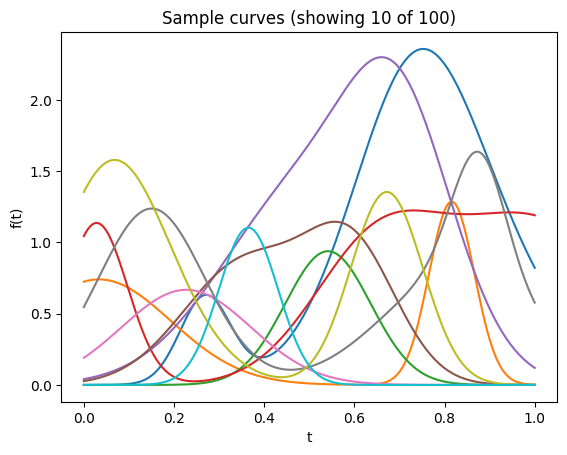

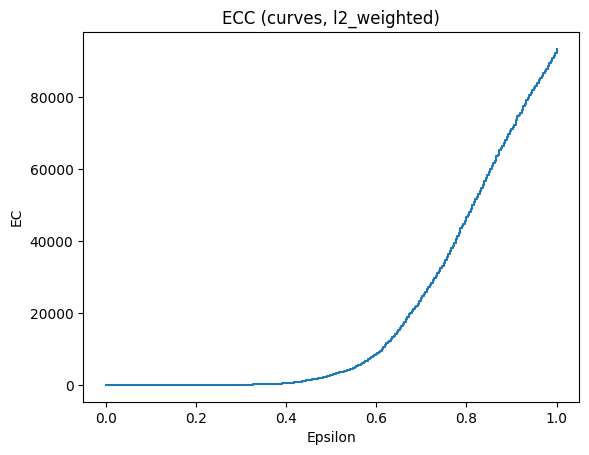

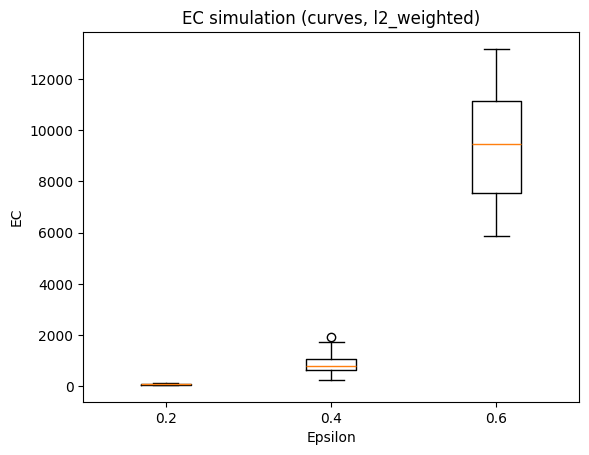

In [29]:
if __name__ == "__main__":
    # 1) Generate functional data (curves)
    t = make_grid(0.0, 1.0, 200)
    X = sample_curves("bumps", n=100, t=t, seed=0, noise=0)
    plot_curves(t, X, k=10, title="Sample curves")

    # Choose a metric once so everything stays consistent
    metric = "l2_weighted"          # or "l2_weighted", "linf", "euclidean"
    h1_lambda = 2.0        # only used if metric == "h1"

    # 2) ECC over an epsilon range
    eps_min, eps_max = 0.0, 1
    C = local_contributions_vr(
        X, eps_max, max_dim=2, metric=metric, t=t, h1_lambda=h1_lambda
    )
    r, ecc = ECC_from_C(C, eps_min, eps_max, num=300)
    plot_ecc(r, ecc, title=f"ECC (curves, {metric})")

    # 3) Discrete EC + bootstrap simulation
    eps_list = [0.2, 0.4, 0.6]
    sim = run_ec_simulation(
        X, eps_list, trials=30, max_dim=2, seed=0,
        metric=metric, t=t, h1_lambda=h1_lambda
    )

    # Boxplot
    plt.figure()
    data = [sim[e] for e in eps_list]
    plt.boxplot(data, tick_labels=[f"{e:.2g}" for e in eps_list], showfliers=True)
    plt.xlabel("Epsilon")
    plt.ylabel("EC")
    plt.title(f"EC simulation (curves, {metric})")
    plt.show()